In [2]:
# Imports for data handling, visualization, and model development (sklearn)
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns
import joblib
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix
from scipy.stats import randint

import sys
sys.path.append("..")
from production.config import DATA_DIR, MODELS_DIR

# Load latest dataset
df = pd.read_csv(DATA_DIR / "latest.csv")

In [3]:
# Visualising up-to-date Dataframe
df.head()

,age,gender,height_cm,weight_kg,duration_minutes,intensity,calories_burned,hours_sleep,stress_level,daily_steps,hydration_level,activity_type
0,56,F,165.3,53.7,41,Low,3.3,6.6,3,7128,1.5,Dancing
1,56,F,165.3,53.9,28,Low,2.9,8.1,7,7925,1.8,Swimming
2,56,F,165.3,54.2,21,Medium,2.6,6.2,7,7557,2.7,Swimming
3,56,F,165.3,54.4,99,Medium,10.7,7.2,8,11120,2.6,Weight Training
4,56,F,165.3,54.7,100,Medium,12.7,7.1,1,5406,1.5,Swimming


In [4]:
# Summary stats (min/mean/max) for key metrics by activity type.
df.groupby("activity_type").agg({
    "duration_minutes": ["min","mean","max"],
    "calories_burned": ["min","mean","max"],
    "daily_steps": ["min","mean","max"],
    "hours_sleep": ["min","mean","max"],
    "stress_level": ["min","mean","max"],
    "hydration_level": ["min","mean","max"]
})

duration_minutes                 calories_burned             \
                             min       mean  max             min       mean   
activity_type                                                                 
Basketball                    20  70.137636  120             2.2  17.357854   
Cycling                       20  70.096955  120             2.2  18.498666   
Dancing                       20  70.235891  120             1.5  11.990842   
HIIT                          20  69.833674  120             3.3  25.994067   
Running                       20  70.047330  120             2.6  21.327712   
Swimming                      20  70.068835  120             1.8  15.188164   
Tennis                        20  70.012928  120             2.0  15.846632   
Walking                       20  69.887875  120             1.0   8.229457   
Weight Training               20  70.021160  120             1.5  13.040469   
Yoga                          20  69.778991  120             0.8   6.506351   

                      daily_steps                     hours_sleep            \
                  max         min         mean    max         min      mean   
activity_type                                                                 
Basketball       60.1         733  8634.183363  17241         4.0  7.050962   
Cycling          72.5        1176  8607.202784  16864         4.0  7.044023   
Dancing          43.1        1115  8622.660544  16696         4.0  7.044990   
HIIT             92.0         609  8630.641836  16601         4.0  7.051561   
Running          84.0        1444  8618.464428  16500         4.0  7.047657   
Swimming         53.2         472  8646.170567  16360         4.0  7.048101   
Tennis           53.9        1042  8620.056995  16793         4.0  7.048005   
Walking          28.9          36  8635.774561  16689         4.0  7.048118   
Weight Training  50.4         345  8636.946886  16290         4.0  7.051059   
Yoga             22.2        1003  8631.860008  16197         4.0  7.053373   

                      stress_level               hydration_level            \
                  max          min      mean max             min      mean   
activity_type                                                                
Basketball       10.0            1  5.242413  10             1.5  2.499006   
Cycling          10.0            1  5.247633  10             1.5  2.498867   
Dancing          10.0            1  5.260908  10             1.5  2.500501   
HIIT             10.0            1  5.253906  10             1.5  2.499591   
Running          10.0            1  5.245439  10             1.5  2.495146   
Swimming         10.0            1  5.246634  10             1.5  2.500766   
Tennis           10.0            1  5.270633  10             1.5  2.498834   
Walking          10.0            1  5.249339  10             1.5  2.503702   
Weight Training  10.0            1  5.250858  10             1.5  2.500567   
Yoga             10.0            1  5.255785  10             1.5  2.497264   

                      
                 max  
activity_type         
Basketball       3.5  
Cycling          3.5  
Dancing          3.5  
HIIT             3.5  
Running          3.5  
Swimming         3.5  
Tennis           3.5  
Walking          3.5  
Weight Training  3.5  
Yoga             3.5

In [7]:
# Grab X(features) and y(target) from latest version of dataset
X = df.drop(['activity_type'], axis=1)
y = df['activity_type']

## Menstrual-Phase Proxy feature

#### **STEP 1:** Use existing pipeline to prepare the data 
- All numerical and categorical inputs must be consistent format, before menstrual feature generation
- Reuse the existing preprocessing pipeline (**scaling + one-hot + ordinal encoding**)
- Apply **pipeline.named_steps['preprocessor'].transform(X)** without refitting
- No leakage occurs because the pipeline is only fit on **X_train**

In [8]:
# Load pipeline used for baseline model
pipeline = joblib.load("../models/fitted_pipeline.pkl")

In [9]:
# Use the existing pipeline to transform the data (no fitting!)
X_TRANS = pipeline.named_steps["preprocessor"].transform(X)
# Get column names from dataset
X_NAMES = pipeline.named_steps["preprocessor"].get_feature_names_out()

In [10]:
# Whole dataframe tranformed
X_MENSTRUAL = pd.DataFrame(X_TRANS, columns=X_NAMES)

In [11]:
# checks
X_MENSTRUAL.head(1)

,nums__age,nums__height_cm,nums__weight_kg,nums__duration_minutes,nums__hours_sleep,nums__daily_steps,nums__calories_burned,nums__hydration_level,nums__stress_level,onehot__gender_F,onehot__gender_M,onehot__gender_Other,ordinal__intensity
0,1.055712,-0.360111,-1.834214,-0.996037,-0.461261,-0.7307,-1.210025,-1.72589,-0.813626,1.0,0.0,0.0,0.0


#### **STEP 2:** Use existing pipeline to prepare the data 
- Combine menstrual-relevant features (**duration, calories burned, intensity, sleep, stress**) into one score
- Use a **weighted sum** to reflect how strongly each factor changes across the menstrual cycle
- Weights come from:
    - Feature importance from the baseline model
    - Research on how energy levels shift across phases
- Higher scores represent higher energy availability


In [12]:
def get_phase_score(df, drtn, cls, intns, slp, strss):
    """
    Compute a menstrual-phase proxy score using weighted interpolation of
    key physiological features.

    Parameters
    ----------
    df : pandas.DataFrame
        The encoded dataset containing model-ready numerical features.

    drtn : float
        Weight assigned to workout duration.
    cls : float
        Weight assigned to calories burned.
    intns : float
        Weight assigned to exercise intensity.
    slp : float
        Weight assigned to hours of sleep.
    strss : float
        Weight applied to stress level (subtracted because high stress lowers energy).

    Returns
    -------
    df : pandas.DataFrame
        The same dataframe with an additional column:
        - 'imp_score' : the unnormalised menstrual energy score.
    """

    df['phase_score'] = (
        drtn * df['nums__duration_minutes'] + 
        cls * df['nums__calories_burned'] +
        intns * df['ordinal__intensity'] +
        slp * df['nums__hours_sleep'] -
        strss * df['nums__stress_level']
    )

    return df

In [13]:
# Generating phase score for df
X_MENSTRUAL = get_phase_score(X_MENSTRUAL, drtn=0.25, cls=0.3, intns=0.2, slp=0.1, strss=0.1)

In [14]:
# Visualising df with phase score added
X_MENSTRUAL.head(3)

,nums__age,nums__height_cm,nums__weight_kg,nums__duration_minutes,nums__hours_sleep,nums__daily_steps,nums__calories_burned,nums__hydration_level,nums__stress_level,onehot__gender_F,onehot__gender_M,onehot__gender_Other,ordinal__intensity,phase_score
0,1.055712,-0.360111,-1.834214,-0.996037,-0.461261,-0.730700,-1.210025,-1.725890,-0.813626,1.0,0.0,0.0,0.0,-0.576780
1,1.055712,-0.360111,-1.825316,-1.442233,1.080868,-0.342945,-1.250081,-1.207804,0.630112,1.0,0.0,0.0,0.0,-0.690507
2,1.055712,-0.360111,-1.811970,-1.682492,-0.872495,-0.521984,-1.280124,0.346452,0.630112,1.0,0.0,0.0,1.0,-0.754921


#### **STEP 3:** Normalise the score

- Convert the raw weighted score into **a 0–1** range using **MinMax** scaling
- Normalisation keeps the scale consistent with other pipeline features
- The scaling step is done once on the **whole dataset** because
    - It is not a predictive feature
  - It is only used to map into categorical cycle phases
  - No label leakage occurs

In [15]:
# Creating scaler object of min max
scaler = MinMaxScaler()

In [16]:
# Normalising phase score column
X_MENSTRUAL['phase_norm'] = scaler.fit_transform(X_MENSTRUAL[['phase_score']])

In [17]:
# Checking MinMax scaler worked 
X_MENSTRUAL.head()

,nums__age,nums__height_cm,nums__weight_kg,nums__duration_minutes,nums__hours_sleep,nums__daily_steps,nums__calories_burned,nums__hydration_level,nums__stress_level,onehot__gender_F,onehot__gender_M,onehot__gender_Other,ordinal__intensity,phase_score,phase_norm
0,1.055712,-0.360111,-1.834214,-0.996037,-0.461261,-0.730700,-1.210025,-1.725890,-0.813626,1.0,0.0,0.0,0.0,-0.576780,0.164217
1,1.055712,-0.360111,-1.825316,-1.442233,1.080868,-0.342945,-1.250081,-1.207804,0.630112,1.0,0.0,0.0,0.0,-0.690507,0.138596
2,1.055712,-0.360111,-1.811970,-1.682492,-0.872495,-0.521984,-1.280124,0.346452,0.630112,1.0,0.0,0.0,1.0,-0.754921,0.124084
3,1.055712,-0.360111,-1.803072,0.994684,0.155591,1.211482,-0.468975,0.173757,0.991047,1.0,0.0,0.0,1.0,0.224433,0.344719
4,1.055712,-0.360111,-1.789725,1.029007,0.052782,-1.568485,-0.268691,-1.725890,-1.535496,1.0,0.0,0.0,1.0,0.535472,0.414792


In [18]:
# Checking range between 0-1 for after scaler
X_MENSTRUAL['phase_norm'].describe()

count    687699.000000
mean          0.334648
std           0.124197
min           0.000000
25%           0.240193
50%           0.324746
75%           0.417161
max           1.000000
Name: phase_norm, dtype: float64

#### **STEP 4:** Map normalised score to menstrual phases
- Convert the normalised score into one of four phases
- Mapping based on research-backed energy profiles:
| **Phase**  | **Energy Level** | **Normalised Range** |
| ---------- | ---------------- | -------------------- |
| Menstrual  | Lowest           | ≤ 0.25               |
| Luteal     | Low              | 0.25–0.50            |
| Follicular | Medium           | 0.50–0.75            |
| Ovulatory  | High             | ≥ 0.75               |

- Ensure only females recieve menstrual phase

In [19]:
def map_phase(score):
    # Map the normalized phase score to one of four menstrual phases (0-3)
    if score <= 0.25:
        return 0  # Menstrual (lowest)
    elif score <= 0.50:
        return 1  # Luteal (low)
    elif score <= 0.75:
        return 2  # Follicular (medium)
    else:
        return 3  # Ovulatory (highest)

In [20]:
def map_phase_with_gender(row):
    # Apply menstrual phase mapping only to female individuals
    # Male / Other = Neutral
    if row['onehot__gender_F'] == 1:
        return map_phase(row['phase_norm'])
    else:
        return -1  

In [21]:
# Apply the map_phase_with_gender function row-wise to create the 'phase_encoded' column
X_MENSTRUAL['phase_encoded'] = X_MENSTRUAL.apply(map_phase_with_gender, axis=1)

In [22]:
# Check added phase_encoded column correctly
X_MENSTRUAL

,nums__age,nums__height_cm,nums__weight_kg,nums__duration_minutes,nums__hours_sleep,nums__daily_steps,nums__calories_burned,nums__hydration_level,nums__stress_level,onehot__gender_F,onehot__gender_M,onehot__gender_Other,ordinal__intensity,phase_score,phase_norm,phase_encoded
0,1.055712,-0.360111,-1.834214,-0.996037,-0.461261,-0.730700,-1.210025,-1.725890,-0.813626,1.0,0.0,0.0,0.0,-0.576780,0.164217,0
1,1.055712,-0.360111,-1.825316,-1.442233,1.080868,-0.342945,-1.250081,-1.207804,0.630112,1.0,0.0,0.0,0.0,-0.690507,0.138596,0
2,1.055712,-0.360111,-1.811970,-1.682492,-0.872495,-0.521984,-1.280124,0.346452,0.630112,1.0,0.0,0.0,1.0,-0.754921,0.124084,0
3,1.055712,-0.360111,-1.803072,0.994684,0.155591,1.211482,-0.468975,0.173757,0.991047,1.0,0.0,0.0,1.0,0.224433,0.344719,1
4,1.055712,-0.360111,-1.789725,1.029007,0.052782,-1.568485,-0.268691,-1.725890,-1.535496,1.0,0.0,0.0,1.0,0.535472,0.414792,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687694,-0.269491,-0.316361,0.799503,-0.893069,0.361208,-0.836275,-0.218620,-1.035109,0.269177,1.0,0.0,0.0,1.0,-0.079650,0.276213,1
687695,-0.269491,-0.316361,0.808401,-1.545201,1.492103,0.146979,-0.909599,0.173757,0.269177,1.0,0.0,0.0,0.0,-0.536887,0.173204,0
687696,-0.269491,-0.316361,0.821747,0.926038,1.183677,0.113896,-0.629202,-1.207804,0.991047,1.0,0.0,0.0,0.0,0.062012,0.308128,1
687697,-0.269491,-0.316361,0.830645,1.303589,1.492103,-0.571609,1.724132,-0.689719,-0.452692,1.0,0.0,0.0,1.0,1.237616,0.572975,2


In [23]:
# Dropping phase score and norm
X_MENSTRUAL = X_MENSTRUAL.drop(columns=['phase_score', 'phase_norm'], errors='ignore')
X_MENSTRUAL

,nums__age,nums__height_cm,nums__weight_kg,nums__duration_minutes,nums__hours_sleep,nums__daily_steps,nums__calories_burned,nums__hydration_level,nums__stress_level,onehot__gender_F,onehot__gender_M,onehot__gender_Other,ordinal__intensity,phase_encoded
0,1.055712,-0.360111,-1.834214,-0.996037,-0.461261,-0.730700,-1.210025,-1.725890,-0.813626,1.0,0.0,0.0,0.0,0
1,1.055712,-0.360111,-1.825316,-1.442233,1.080868,-0.342945,-1.250081,-1.207804,0.630112,1.0,0.0,0.0,0.0,0
2,1.055712,-0.360111,-1.811970,-1.682492,-0.872495,-0.521984,-1.280124,0.346452,0.630112,1.0,0.0,0.0,1.0,0
3,1.055712,-0.360111,-1.803072,0.994684,0.155591,1.211482,-0.468975,0.173757,0.991047,1.0,0.0,0.0,1.0,1
4,1.055712,-0.360111,-1.789725,1.029007,0.052782,-1.568485,-0.268691,-1.725890,-1.535496,1.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687694,-0.269491,-0.316361,0.799503,-0.893069,0.361208,-0.836275,-0.218620,-1.035109,0.269177,1.0,0.0,0.0,1.0,1
687695,-0.269491,-0.316361,0.808401,-1.545201,1.492103,0.146979,-0.909599,0.173757,0.269177,1.0,0.0,0.0,0.0,0
687696,-0.269491,-0.316361,0.821747,0.926038,1.183677,0.113896,-0.629202,-1.207804,0.991047,1.0,0.0,0.0,0.0,1
687697,-0.269491,-0.316361,0.830645,1.303589,1.492103,-0.571609,1.724132,-0.689719,-0.452692,1.0,0.0,0.0,1.0,2


In [24]:
# Drop gender: it has little impact on the target and menstrual data already captures this info
cols_to_drop = [
    "onehot__gender_F",
    "onehot__gender_M",
    "onehot__gender_Other"
]
X_MENSTRUAL = X_MENSTRUAL.drop(columns=cols_to_drop)

In [25]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_MENSTRUAL,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

In [26]:
# Display the training features DataFrame
X_train

,nums__age,nums__height_cm,nums__weight_kg,nums__duration_minutes,nums__hours_sleep,nums__daily_steps,nums__calories_burned,nums__hydration_level,nums__stress_level,ordinal__intensity,phase_encoded
659982,-1.594693,-1.169497,-0.877712,0.960361,-0.152835,-0.076819,-0.448946,-1.553194,1.351981,2.0,1
422375,1.055712,-0.786680,-0.971138,0.960361,-0.152835,0.780426,0.051763,-0.517024,1.712916,0.0,1
9184,0.761223,-0.950744,-0.552946,-0.549841,-0.975304,0.483164,-0.458961,0.346452,-1.174561,1.0,1
165616,1.129335,0.263335,-0.997831,-0.275259,-1.386538,-0.451925,-0.268691,-1.380499,1.351981,1.0,-1
525105,-1.300204,-0.097608,0.274539,-0.824423,0.155591,-0.010653,-0.769400,0.864538,1.712916,0.0,-1
...,...,...,...,...,...,...,...,...,...,...,...
387993,0.982090,0.810217,0.114381,0.720102,1.080868,0.772642,0.822855,1.037233,-0.091757,1.0,-1
449255,-0.563980,1.411788,1.346711,1.269266,0.772443,-0.548256,1.623990,-1.380499,-0.452692,0.0,-1
83463,-0.195868,0.252397,-0.366095,0.720102,2.314572,0.178116,0.372217,1.037233,1.351981,1.0,-1
189845,0.687600,1.236786,0.372414,-0.687132,1.183677,0.046756,-0.168549,0.691843,0.630112,1.0,-1


In [27]:
# Convert to float32 to reduce memory usage and model size
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

In [26]:
# Visualising columns
print(list(X_train.columns))


['nums__age', 'nums__height_cm', 'nums__weight_kg', 'nums__duration_minutes', 'nums__hours_sleep', 'nums__daily_steps', 'nums__calories_burned', 'nums__hydration_level', 'nums__stress_level', 'ordinal__intensity', 'phase_encoded']


In [27]:
# Train a Random Forest model with tuned hyperparameters
MODEL = RandomForestClassifier(n_estimators=120, 
                               max_depth=22, 
                               n_jobs=-1, 
                               random_state=42)

# Training model
MODEL.fit(X_train, y_train)

,n_estimators,120
,criterion,'gini'
,max_depth,22
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
# Get predicitions from model output
y_pred = MODEL.predict(X_test)
# Print classification report
print(classification_report(y_test, y_pred))


                 precision    recall  f1-score   support

     Basketball       0.80      0.73      0.76     13707
        Cycling       0.79      0.83      0.81     13838
        Dancing       0.90      0.94      0.92     13839
           HIIT       0.99      1.00      0.99     13875
        Running       0.97      0.98      0.97     13429
       Swimming       0.69      0.71      0.70     13606
         Tennis       0.68      0.64      0.66     13707
        Walking       1.00      0.99      0.99     13615
Weight Training       0.91      0.89      0.90     13932
           Yoga       0.99      1.00      0.99     13992

       accuracy                           0.87    137540
      macro avg       0.87      0.87      0.87    137540
   weighted avg       0.87      0.87      0.87    137540



In [29]:
# Save final model trained on original features + menstrual
joblib.dump(MODEL, "../models/rf_activity_87pct.pkl", compress=3)

['../models/rf_activity_87pct.pkl']

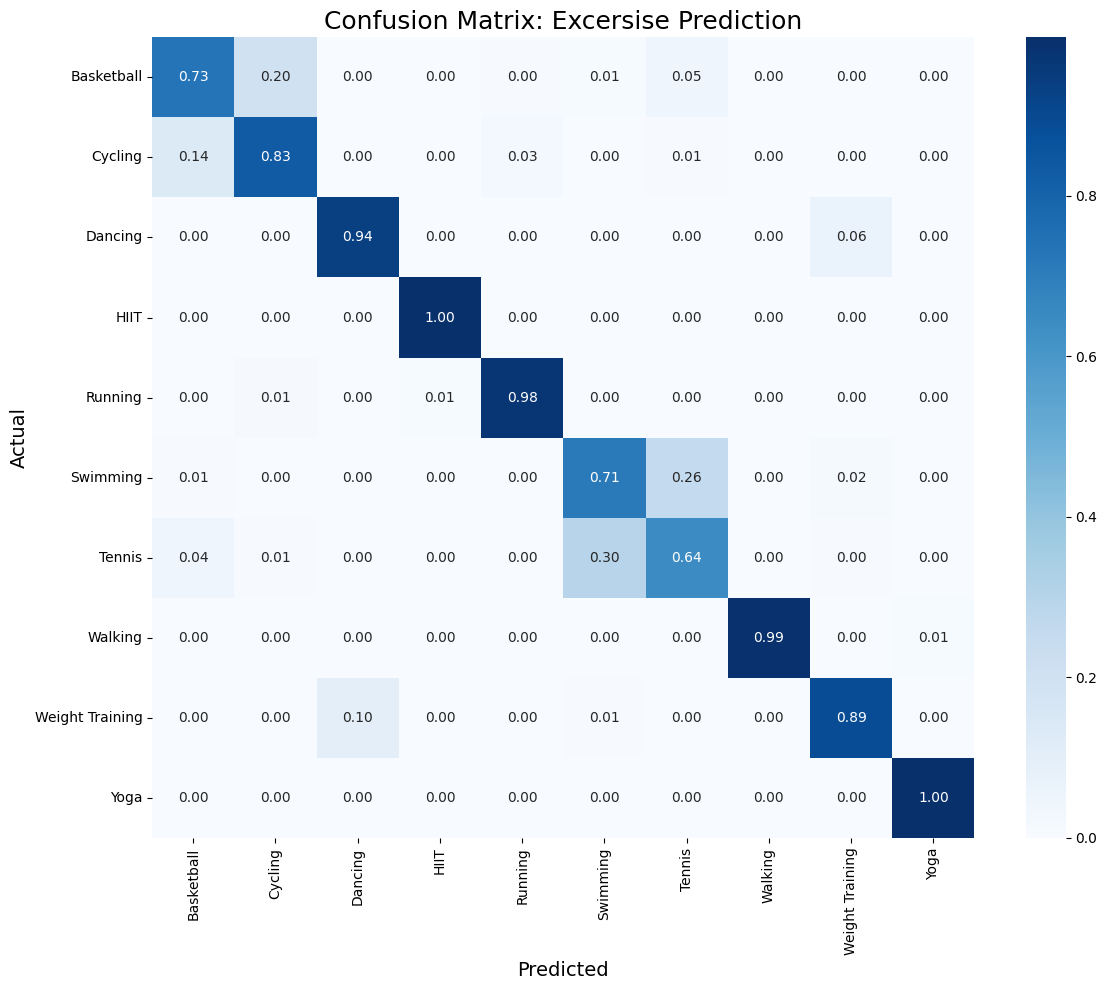

In [30]:
# Create confusion matrix and normalize rows
cm = confusion_matrix(y_test, y_pred, labels=MODEL.classes_)
cm_norm = cm / cm.sum(axis=1)[:, None]  

# Plot normalized confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",      
    cmap="Blues",
    cbar=True,
    xticklabels=MODEL.classes_,
    yticklabels=MODEL.classes_
)

plt.title("Confusion Matrix: Excersise Prediction", fontsize=18)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("Actual", fontsize=14)
plt.tight_layout()
plt.show()